# Тестовое задание

## Контекст

Есть фрагмент Python-скрипта для подготовки аналитического отчёта.  
Скрипт работает с SQL-выгрузками, обрабатывает данные в `pandas` и строит графики.  
В реальной работе код большой, поэтому важно не просто написать решение, а **внести изменения аккуратно, локально и так, чтобы не сломать существующую логику**.

---

## Что нужно сделать

Ниже даны фрагменты кода. Нужно внести в них точечные изменения и кратко объяснить свои решения.


## Задания

### 1. Доработка функции `graphdynamic`

Сейчас все редкие категории объединяются в значение **`"Другое"`** всегда.  
Нужно изменить логику так, чтобы:

- если `max_rows == None`, категории **не объединялись** в `"Другое"`
- если `max_rows` передан числом, текущее поведение сохранялось

### 2. Безопасный расчёт долей

Сейчас в функции есть расчёт:

```python
df['percent_amount'] = df['amount'] / df['amount_quarter']
```

Нужно обработать ситуацию, когда `amount_quarter = 0`, чтобы в percent_amount не оставались неконтролируемые NaN или inf.

Решение нужно **кратко пояснить**.

### 3. Доработка логики SQL-фильтра

В функции transform_filtr_mt нужно исправить обработку фильтра filtr_mt:
- для topic_alias фильтр должен строиться через dictionary.banner и banner_id
- для user_id in (...) должна сохраняться текущая замена на dictGet('campaign', 'user_id', toUInt64(campaign_id))
- для campaign_id in (...) фильтр должен оставаться без изменений

Важно: не переписывайте функцию полностью, постарайтесь внести локальные правки.

---

## Что нужно прислать

1.	Изменённую функцию graphdynamic
2.	Изменённый блок обработки filtr_mt
3.	Короткое пояснение по изменениям
4.	Пример запуска на df_test


## Тестовые данные для самопроверки

Можно использовать такой пример, чтобы быстро проверить свою доработку функции `graphdynamic`:


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Вспомогательные функции-заглушки для теста
# -----------------------------
color_theme = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948']

def addempty_columns_periods(dfgraph, listofcolumns):
    dfgraph = dfgraph.copy()
    for col in listofcolumns:
        if col not in dfgraph.columns:
            dfgraph[col] = 0
    return dfgraph[listofcolumns]

def addempty_columns(dfgraph, listofcolumns):
    dfgraph = dfgraph.copy()
    for col in listofcolumns:
        if col not in dfgraph.columns:
            dfgraph[col] = 0
    return dfgraph[listofcolumns]

def framesof(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)


# -----------------------------
# Тестовые данные
# -----------------------------

df_test = pd.DataFrame({
    'period': [
        '2026-01','2026-01','2026-01',
        '2026-02','2026-02','2026-02',
        '2026-02','2026-02',
        '2026-01','2026-02','2026-02','2026-01'
    ],
    'Для кого отчет?': [
        'Клиент A','Клиент A','Клиент B',
        'Клиент A','Клиент B','Клиент B',
        'Клиент C','Клиент C',
        'Клиент B','Клиент A','Клиент C','Клиент C'
    ],
    'Формат': [
        'Видео','Баннер','Видео',
        'Видео','Баннер','Вертикальное видео',
        'Видео','Видео',
        'Универсальный баннер','Универсальный баннер','Баннер','Вертикальное видео'
    ],
    'amount': [
        100,0,50,
        200,100,0,
        0,0,
        30,70,0,10
    ]
})

column = 'Формат'
df_test['period'] = pd.to_datetime(df_test['period'])
clients_test = df_test['Для кого отчет?'].unique().tolist()

df_test

,period,Для кого отчет?,Формат,amount
0,2026-01-01,Клиент A,Видео,100
1,2026-01-01,Клиент A,Баннер,0
2,2026-01-01,Клиент B,Видео,50
3,2026-02-01,Клиент A,Видео,200
4,2026-02-01,Клиент B,Баннер,100
5,2026-02-01,Клиент B,Вертикальное видео,0
6,2026-02-01,Клиент C,Видео,0
7,2026-02-01,Клиент C,Видео,0
8,2026-01-01,Клиент B,Универсальный баннер,30
9,2026-02-01,Клиент A,Универсальный баннер,70


## Фрагмент 1. Функция построения графика


In [2]:
def graphdynamic(df, column, max_rows, clients, split_by_period = True, fig_width = 15, filter_condition=None):
    width = 0.8
    fig, axs = plt.subplots(1, len(clients), figsize=(fig_width, 4.5), sharey=True)
    
    listofcolumns = df.groupby([column])['amount'].sum().reset_index().sort_values(by='amount', ascending=False)[column].head(max_rows).tolist()
    df.loc[~df[column].isin(listofcolumns), column] = 'Другое'
    listofcolumns = df.groupby([column])['amount'].sum().reset_index().sort_values(by='amount', ascending=False)[column].tolist()
    if split_by_period:
        df = df.groupby(['period', column, 'Для кого отчет?'])[['amount']].sum().reset_index()
        dop = df.groupby(['period', 'Для кого отчет?'])[['amount']].sum().reset_index()
        dop = dop.rename(columns={"amount": "amount_quarter"})
        df = pd.merge(df, dop, how="left", on=["period", "Для кого отчет?"])
        df['percent_amount'] = df['amount'] / df['amount_quarter']
        df = df[['Для кого отчет?', 'period', column, 'percent_amount', 'amount']]
    else:
        df = df.groupby([column, 'Для кого отчет?'])[['amount']].sum().reset_index()
        dop = df.groupby(['Для кого отчет?'])[['amount']].sum().reset_index()
        dop = dop.rename(columns={"amount": "amount_quarter"})
        df = pd.merge(df, dop, how="left", on=[ "Для кого отчет?"])
        df['percent_amount'] = df['amount'] / df['amount_quarter']
        df = df[['Для кого отчет?', column, 'percent_amount', 'amount']]
        
    if filter_condition is not None:
        df = df[filter_condition]
    
    for i, client in enumerate(clients):
        if split_by_period:
            dfgraph = df[df['Для кого отчет?'] == client].pivot(index='period', columns=column, values='percent_amount')
            dfgraph = addempty_columns_periods(dfgraph, listofcolumns)
        else:
            dfgraph = df[df['Для кого отчет?'] == client].pivot(index='Для кого отчет?', columns=column, values='percent_amount')
            if filter_condition is None:
                dfgraph = addempty_columns(dfgraph, listofcolumns)
        
        if len(clients)==1:
            ax=axs
        else:    
            ax = axs[i]
            
        dfgraph.plot.bar(ax=ax, stacked=True, color=color_theme, width=width, legend=False)

        if i==0 and filter_condition is None:
            if len(clients)==1:
                bbox_right=0.5
            if len(clients)==2:
                bbox_right=1.1
            if len(clients)==3:
                bbox_right=1.6
            if len(clients)>=4:
                bbox_right = len(clients)*0.5 + 0.4
            ax.legend(loc='upper center', bbox_to_anchor=(bbox_right, -0.1), ncol=5,frameon=False)
        
        ax.tick_params(bottom=False)
        ax.get_yaxis().set_visible(False)
        
        if len(clients) > 1 and split_by_period:
            ax.set_title(client)
        
        framesof(ax)
        ax.tick_params(axis='x', labelrotation=0)
        x_axis = ax.xaxis
        x_axis.label.set_visible(False)
        
        if filter_condition is not None:
            for container in ax.containers:
                ax.bar_label(container, labels=[f'{x:.0%}' for x in container.datavalues], label_type='center')
        else:
            for container in ax.containers:
                ax.bar_label(container, labels=[f'{x:.0%}' if x > 0.02 else "" for x in container.datavalues], label_type='center')

Что нужно сделать:
1. Доработать функцию так, чтобы при max_rows=None категории не объединялись в "Другое".
2. Обработать ситуацию, когда amount_quarter = 0, чтобы в percent_amount не оставались неконтролируемые NaN или inf.
3. Проверить решение на df_test.

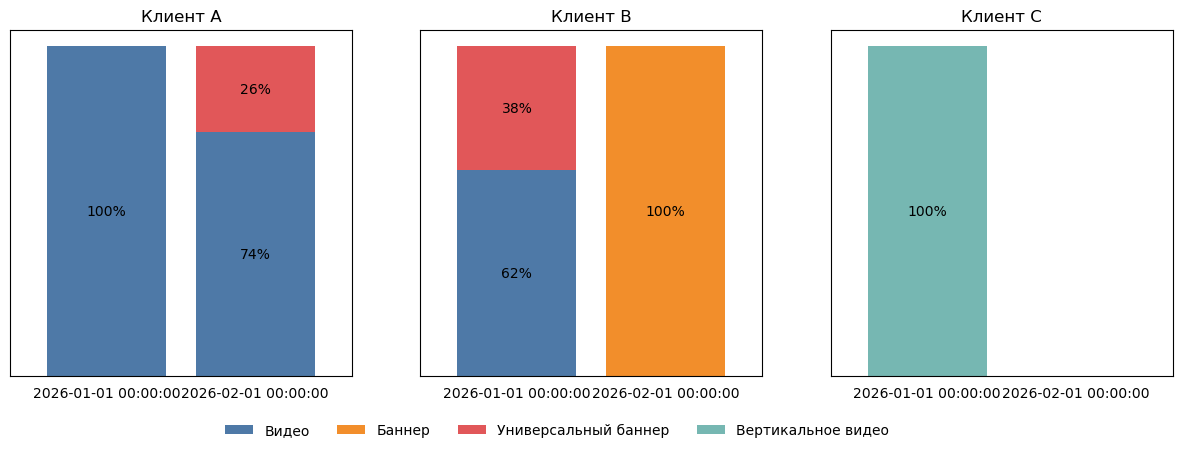

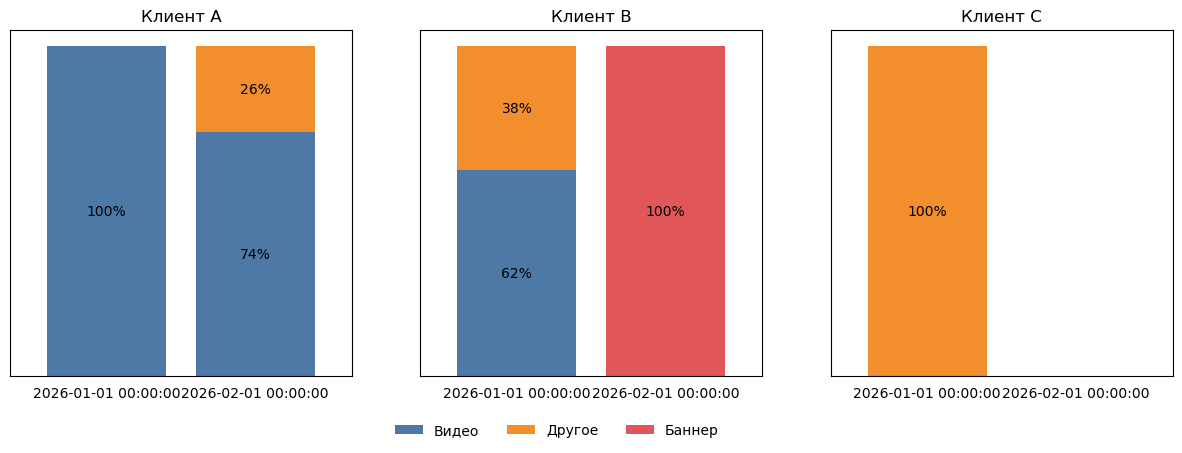

,period,Формат,Для кого отчет?,amount,amount_quarter,percent_amount
0,2026-01-01,Баннер,Клиент A,0,100,0.000000
1,2026-01-01,Видео,Клиент A,100,100,1.000000
2,2026-02-01,Видео,Клиент A,200,270,0.740741
3,2026-02-01,Универсальный баннер,Клиент A,70,270,0.259259
4,2026-01-01,Видео,Клиент B,50,80,0.625000
5,2026-01-01,Универсальный баннер,Клиент B,30,80,0.375000
6,2026-02-01,Баннер,Клиент B,100,100,1.000000
7,2026-02-01,Вертикальное видео,Клиент B,0,100,0.000000
8,2026-01-01,Вертикальное видео,Клиент C,10,10,1.000000
9,2026-02-01,Баннер,Клиент C,0,0,NaN


,period,Формат,Для кого отчет?,amount,amount_quarter,percent_amount
0,2026-01-01,Баннер,Клиент A,0,100,0.000000
1,2026-01-01,Видео,Клиент A,100,100,1.000000
2,2026-02-01,Видео,Клиент A,200,270,0.740741
3,2026-02-01,Другое,Клиент A,70,270,0.259259
4,2026-01-01,Видео,Клиент B,50,80,0.625000
5,2026-01-01,Другое,Клиент B,30,80,0.375000
6,2026-02-01,Баннер,Клиент B,100,100,1.000000
7,2026-02-01,Другое,Клиент B,0,100,0.000000
8,2026-01-01,Другое,Клиент C,10,10,1.000000
9,2026-02-01,Баннер,Клиент C,0,0,NaN


Для max_rows=None есть 'Другое': False
Для max_rows=2 есть 'Другое': True
Для max_rows=None есть inf: False
Для max_rows=None есть NaN: True
Для max_rows=2 есть inf: False
Для max_rows=2 есть NaN: True


In [3]:
# код для самопроверки
# Ожидаемое поведение после исправления:
# 1. Для max_rows=None значение "Другое" не должно появляться
# 2. Для max_rows=2 значение "Другое" должно появляться
# 3. В колонке percent_amount не должно оставаться неконтролируемых NaN / inf

def check_percent_table(df, column, max_rows):
    df = df.copy()

    if max_rows is not None:
        listofcolumns = (
            df.groupby(column)['amount']
            .sum()
            .reset_index()
            .sort_values(by='amount', ascending=False)[column]
            .head(max_rows)
            .tolist()
        )
        df.loc[~df[column].isin(listofcolumns), column] = 'Другое'

    df = df.groupby(['period', column, 'Для кого отчет?'])[['amount']].sum().reset_index()
    dop = df.groupby(['period', 'Для кого отчет?'])[['amount']].sum().reset_index()
    dop = dop.rename(columns={'amount': 'amount_quarter'})
    df = pd.merge(df, dop, how='left', on=['period', 'Для кого отчет?'])

    df['percent_amount'] = df['amount'] / df['amount_quarter']

    return df.sort_values(['Для кого отчет?', 'period', column]).reset_index(drop=True)



# Проверка графиков
graphdynamic(df_test.copy(), 'Формат', None, clients_test)
plt.show()

graphdynamic(df_test.copy(), 'Формат', 2, clients_test)
plt.show()

# Проверка расчетной таблицы
check_none = check_percent_table(df_test.copy(), 'Формат', None)
check_two = check_percent_table(df_test.copy(), 'Формат', 2)

display(check_none)
display(check_two)

print("Для max_rows=None есть 'Другое':", (check_none['Формат'] == 'Другое').any())
print("Для max_rows=2 есть 'Другое':", (check_two['Формат'] == 'Другое').any())

print("Для max_rows=None есть inf:", np.isinf(check_none['percent_amount']).any())
print("Для max_rows=None есть NaN:", check_none['percent_amount'].isna().any())

print("Для max_rows=2 есть inf:", np.isinf(check_two['percent_amount']).any())
print("Для max_rows=2 есть NaN:", check_two['percent_amount'].isna().any())

## Фрагмент 2. Логика обработки SQL-фильтра


In [4]:
# Доработайте функцию transform_filtr_mt.
# Что нужно сделать:
# 1. Если в фильтре есть topic_alias, нужно формировать фильтр через dictionary.banner:
#    AND banner_id IN (SELECT DISTINCT banner_id FROM dictionary.banner WHERE 1=1{filtr_mt})
# 2. Сохранить текущую логику для user_id in (...)
# 3. Добавить явную обработку случая, когда фильтр начинается с campaign_id in (...)
#    В этом случае фильтр должен оставаться без изменений
# 4. Постарайтесь внести минимальные изменения в существующий код

def transform_filtr_mt(filtr_mt):
    has_topic_alias = 'topic_alias' in filtr_mt.lower()
    starts_with_user_id = bool(
        re.match(r"^\s*and\s+user_id\s+in\s*\(", filtr_mt.strip(), flags=re.IGNORECASE)
    )

    # Сейчас логика ниже некорректна и требует доработки
    if has_topic_alias:
        filtr_mt_dr = filtr_mt
        filtr_mt_vkc = filtr_mt_dr
    else:
        filtr_mt_dr = filtr_mt
        filtr_mt_vkc = filtr_mt_dr

        if starts_with_user_id:
            filtr_mt_vkc = re.sub(
                r"^\s*and\s+user_id\s+in\s*\(",
                "and dictGet('campaign', 'user_id', toUInt64(campaign_id)) in (",
                filtr_mt_dr,
                count=1,
                flags=re.IGNORECASE
            )

    return filtr_mt_dr, filtr_mt_vkc

In [5]:
# Код для самопроверки
test_cases = [
    "and user_id in (100,2232,1633)",
    "and campaign_id in (102232,2023211)",
    "and topic_alias in ('games')"
]

for filtr_mt in test_cases:
    dr, vkc = transform_filtr_mt(filtr_mt)

    print("Исходный фильтр:", filtr_mt)
    print("filtr_mt_dr:    ", dr)
    print("filtr_mt_vkc:   ", vkc)
    print("-" * 80)

Исходный фильтр: and user_id in (100,2232,1633)
filtr_mt_dr:     and user_id in (100,2232,1633)
filtr_mt_vkc:    and dictGet('campaign', 'user_id', toUInt64(campaign_id)) in (100,2232,1633)
--------------------------------------------------------------------------------
Исходный фильтр: and campaign_id in (102232,2023211)
filtr_mt_dr:     and campaign_id in (102232,2023211)
filtr_mt_vkc:    and campaign_id in (102232,2023211)
--------------------------------------------------------------------------------
Исходный фильтр: and topic_alias in ('games')
filtr_mt_dr:     and topic_alias in ('games')
filtr_mt_vkc:    and topic_alias in ('games')
--------------------------------------------------------------------------------


Ожидаемое поведение после доработки:
1. and user_id in (...) 
-> filtr_mt_dr без изменений
-> filtr_mt_vkc с заменой на dictGet('campaign', 'user_id', toUInt64(campaign_id)) in (...)

2. and campaign_id in (...)
-> filtr_mt_dr без изменений
-> filtr_mt_vkc без изменений

3. and topic_alias in (...)
-> и filtr_mt_dr, и filtr_mt_vkc должны стать:
   AND banner_id IN (SELECT DISTINCT banner_id FROM dictionary.banner WHERE 1=1{filtr_mt})

## Важно

- Не нужно полностью переписывать функцию или менять общую структуру кода без необходимости.
- Важно показать, что вы умеете **вносить локальные и понятные изменения** в существующий код.
- В реальных задачах код большой и связан между собой, поэтому аккуратность правок важнее, чем полное переписывание решения с нуля.


## Критерии оценки

При проверке будут оцениваться:

- корректность изменений
- аккуратность и локальность правок
- сохранение текущей логики там, где её не просили менять
- понятность кода и комментариев
- обработка краевых случаев
